In [ ]:

## colab 용 구글 드라이브 마운트
# from google.colab import drive
# drive.mount('/content/drive')

# # 이미지 출력을 위한 import
# from PIL import Image

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# 필요 시 설치
!pip -q install transformers accelerate bitsandbytes peft \
    langchain langchain-community langchain-huggingface chromadb


# 케이팝 데몬 헌터스를 RAG에 먹여봤습니다

- OpenAI API 가 아닌 `HuggingFace` 를 통해 모델을 불러올 예정
  - 한국어를 조금 하는 적당한 모델 종류
    - `Qwen2.5-7B-Instruct` — 다국어 지원에 한국어 포함, 롱컨텍스트 128k. T4(16GB)에서도 4bit로 충분히 굴러감
    - `Llama-3-Open-Ko-8B(Beomi)` — Llama3 기반으로 한국어 계속 사전학습(continued pretraining). 한국어 생성톤 안정적.
    - `Bllossom Llama-3.1 Korean(8B/405B 계열)` — 한국어 자연스러움 강화(405B는 무리, 8B/비전8B가 현실적)
  - 우선 제일 무난한 `Qwen2.5-7B-Instruct` 로 선택

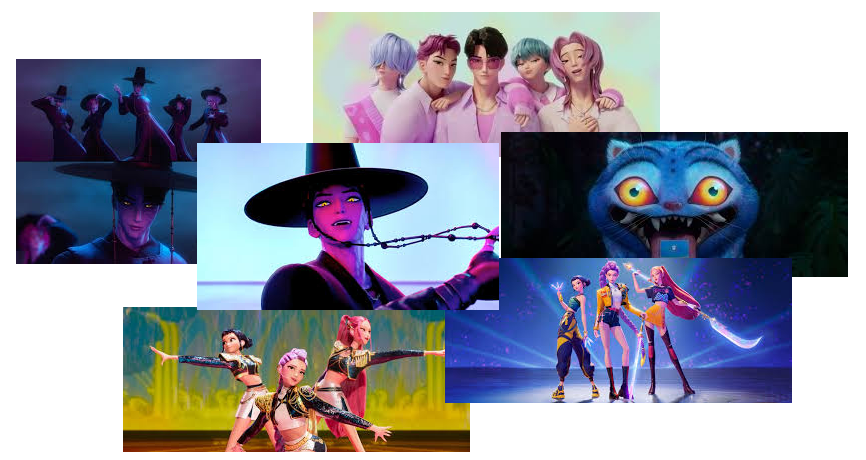

In [ ]:
# 실행하지마세요!
img = Image.open("/content/drive/MyDrive/Colab Notebooks/company/Langchain_Lecture/DemonHunters.png")
display(img)

## 기존 모델 확인하기

- 허깅페이스에서 모델을 가져와 다운로드 후 실행
  - 인터넷 상황에 따라 시간이 오래 걸릴 수 있다.
- 진짜 데몬 헌터스를 모를 지 물어보기
  - 거짓말을 하기도 하고, 모른다고 하기도 한다



In [2]:
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig, pipeline
from langchain_huggingface import HuggingFacePipeline, ChatHuggingFace
from langchain_core.messages import HumanMessage

# Qwen: 다국어 모델
MODEL_ID = "Qwen/Qwen2.5-1.5B-Instruct"  # Qwen/Qwen2.5-7B-Instruct  -> 너무 오래걸림

# 1) 토크나이저/모델 로드 (4bit)
bnb_cfg = BitsAndBytesConfig(
    load_in_4bit=True,                # 4bit 로딩
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype="bfloat16"
)

tok = AutoTokenizer.from_pretrained(MODEL_ID, use_fast=True, trust_remote_code=True)
model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    device_map="auto",
    quantization_config=bnb_cfg,
    dtype="auto",
    trust_remote_code=True
)


In [3]:
# 2) 파이프라인 구성
gen_pipe = pipeline(
    "text-generation",
    model=model,
    tokenizer=tok,
    max_new_tokens=128,
    do_sample=False
)

Device set to use cuda:0
The following generation flags are not valid and may be ignored: ['temperature', 'top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


In [4]:
# 3) LangChain 래퍼 (Chat 인터페이스)
llm_hf = HuggingFacePipeline(pipeline=gen_pipe)
chat_llm = ChatHuggingFace(llm=llm_hf, tokenizer=tok)

def ask(text: str) -> str:
    return chat_llm.invoke([HumanMessage(content=text)]).content

In [5]:
print(ask("사자보이즈(SAjA Boys) 알아?"))

<|im_start|>system
You are Qwen, created by Alibaba Cloud. You are a helpful assistant.<|im_end|>
<|im_start|>user
사자보이즈(SAjA Boys) 알아?<|im_end|>
<|im_start|>assistant
사자보이즈(SAjA Boys)는 대한민국의 음악 그룹입니다. 그룹명에서 알 수 있듯이, 그룹원들이 모두 사자에 대해 특별히 취향을 가진 아이들로 구성되어 있습니다.

그룹은 2017년 8월 30일에 공식 데뷔하여 많은 사랑을 받고 있습니다. 그룹의 멤버들은 각각 다른 성격과 취향을 가지고 있으며, 이는 그룹의 활동과 음악에 큰 영향을 미치고 있습니다.

그룹


## RAG 1단계: 데이터 가져오기

- 자료를 제작한 날(2025/08/13) 기준, GPT-5도 데몬 헌터스 영화에 대한 공개 정보를 찾기 어려워 함
- 다운로드 가능한 공식 데이터나 문서가 없으므로 직접 설정 자료를 제작.
  - 예: [배경지식], [혼문], [헌트릭스], [귀마], [사자 보이즈] 항목별 세계관 설명 작성.

In [6]:
text = """
[배경지식]
인간 세상엔 옛날부터 인간의 영혼을 먹고 사는 악령들이 존재했다.
악령들은 수시로 인간들의 영혼을 먹으려고 쳐들어왔다

[혼문]
악령들이 인간 세상으로 쳐들어 올 수 없도록 하는 봉인
혼문으로 인해 악령들은 인간 세상으로 올 수 없으며
혼문이 완성되면 황금혼문으로 진화하는데,
황금혼문이 완성되면 영원히 악령들은 인간 세상으로 올 수 없다

[헌트릭스]
악령들을 막기 위해 선택된 3명의 그룹
이들은 노래로 사람들의 마음을 모으고, 그 마음을 통해 혼문을 강화한다
사람들의 마음을 모으는 도구로 노래를 선택했고
현재는 3인조 아이돌로 활용하며 노래를 불러 사람들의 마음을 모은다

[귀마]
악령들의 대장이다.
악령들이 인간의 혼을 모으면 귀마에게 전달된다.
악령의 혼을 먹을수록 힘이 강해지며, 황금혼문이 완성되는 걸 막아야 한다.

[사자 보이즈]
황금 혼문을 만들고자 하는 헌트릭스에 대항하기 위해 조직된 보이그룹이며, 실체는 인간의 혼을 노리는 5인조 악령이다.
각 멤버의 이름은 진우, 베이비, 애비, 로맨스, 미스터리이다.
전원이 미남인 만큼 적수인 헌트릭스 멤버들조차도 넘어가버릴 정도며,
사자 보이즈의 무대를 보고 헌트릭스도 무심코 어깨를 둠칫거릴 정도로 능력 자체는 뛰어나다.
악령이지만 의외로 팬들 앞에서는 철저한 퍼포먼스와 프로 정신을 보여주며, 프로 아이돌다운 모습을 유지한다.
그렇다고 이들이 진심으로 팬들을 생각하는 것은 전혀 아니다.
또한 헌트릭스의 노래가 듣는 이와 공명해 혼문을 생성해 내는 반면 사자 보이즈의 노래는 반대로 혼문에 균열을 내는 역할을 한다.
직접적인 전투능력은 리더인 진우를 제외하곤 거의 없다.
팬덤명은 프라이드(Pride)이며, 짧은 시간에 5000만 명을 돌파할 정도로 강력한 팬덤으로 성장했다.
"""

## RAG 2단계: 데이터 전처리
- 긴 텍스트를 그대로 임베딩하면 검색 품질이 떨어질 수 있으므로 `청크 분리` 필수.
  - `RecursiveCharacterTextSplitter`를 사용해 `300~500`자 단위로 분리, `10~30`자 겹침 설정.
  - 각 청크에 필요한 경우 메타데이터(항목명, 카테고리 등) 추가.

In [7]:
from langchain.text_splitter import RecursiveCharacterTextSplitter
splitter = RecursiveCharacterTextSplitter(
    chunk_size=300,
    chunk_overlap=10,
    separators=["\n\n", "\n", " ", ""]
)
docs = splitter.create_documents([text])

print("청크 개수:", len(docs))
print("예시 청크 1:\n", docs[0].page_content[:300])

청크 개수: 4
예시 청크 1:
 [배경지식]
인간 세상엔 옛날부터 인간의 영혼을 먹고 사는 악령들이 존재했다.
악령들은 수시로 인간들의 영혼을 먹으려고 쳐들어왔다

[혼문]
악령들이 인간 세상으로 쳐들어 올 수 없도록 하는 봉인
혼문으로 인해 악령들은 인간 세상으로 올 수 없으며
혼문이 완성되면 황금혼문으로 진화하는데,
황금혼문이 완성되면 영원히 악령들은 인간 세상으로 올 수 없다


## RAG 3단계: 인덱싱(Indexing)
- **분리된 청크(docs)** 를 Hugging Face 임베딩 모델(예: BAAI/bge-m3)로 벡터화한다.
- **벡터스토어(Chroma)** 에 **[벡터 + 원문 텍스트 + 메타데이터]** 를 저장한다.
  - 이후 유사도 검색(top-k)으로 관련 청크를 빠르게 조회.
  - 필요하면 디스크에 **영구 저장(persist)**해서 재시작 후에도 재사용.

In [8]:
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_community.vectorstores import Chroma

emb = HuggingFaceEmbeddings(model_name="BAAI/bge-m3", model_kwargs={'device':'cuda'})  # 다국어 SOTA 계열
vectordb = Chroma.from_documents(docs, embedding=emb, collection_name="kdh")

# 간단 검색 체크
preview = vectordb.similarity_search("사자 보이즈가 뭐야?", k=2)
for i, doc in enumerate(preview, 1):
    print(f"결과 {i}:\n", doc.page_content)
    print("메타데이터:", doc.metadata)


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/123 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/54.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/687 [00:00<?, ?B/s]

...

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/17.1M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/964 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/191 [00:00<?, ?B/s]

결과 1:
 [사자 보이즈]
황금 혼문을 만들고자 하는 헌트릭스에 대항하기 위해 조직된 보이그룹이며, 실체는 인간의 혼을 노리는 5인조 악령이다.
각 멤버의 이름은 진우, 베이비, 애비, 로맨스, 미스터리이다.
전원이 미남인 만큼 적수인 헌트릭스 멤버들조차도 넘어가버릴 정도며,
사자 보이즈의 무대를 보고 헌트릭스도 무심코 어깨를 둠칫거릴 정도로 능력 자체는 뛰어나다.
악령이지만 의외로 팬들 앞에서는 철저한 퍼포먼스와 프로 정신을 보여주며, 프로 아이돌다운 모습을 유지한다.
그렇다고 이들이 진심으로 팬들을 생각하는 것은 전혀 아니다.
메타데이터: {}
결과 2:
 또한 헌트릭스의 노래가 듣는 이와 공명해 혼문을 생성해 내는 반면 사자 보이즈의 노래는 반대로 혼문에 균열을 내는 역할을 한다.
직접적인 전투능력은 리더인 진우를 제외하곤 거의 없다.
팬덤명은 프라이드(Pride)이며, 짧은 시간에 5000만 명을 돌파할 정도로 강력한 팬덤으로 성장했다.
메타데이터: {}


## RAG 4단계: 검색(Retrieval)
- 사용자 질문을 동일한 임베딩 모델로 벡터화.
- 벡터스토어에서 질문 벡터와 유사도가 높은 청크 Top-K를 검색.

In [9]:
retriever = vectordb.as_retriever(search_kwargs={"k": 3})

hits = retriever.invoke("혼문이 뭐야?")
print("검색 결과 수:", len(hits))
for i, d in enumerate(hits, 1):
    print(f"\n[{i}] -----------------------------------")
    print(d.page_content[:250])

검색 결과 수: 3

[1] -----------------------------------
[배경지식]
인간 세상엔 옛날부터 인간의 영혼을 먹고 사는 악령들이 존재했다.
악령들은 수시로 인간들의 영혼을 먹으려고 쳐들어왔다

[혼문]
악령들이 인간 세상으로 쳐들어 올 수 없도록 하는 봉인
혼문으로 인해 악령들은 인간 세상으로 올 수 없으며
혼문이 완성되면 황금혼문으로 진화하는데,
황금혼문이 완성되면 영원히 악령들은 인간 세상으로 올 수 없다

[2] -----------------------------------
[헌트릭스]
악령들을 막기 위해 선택된 3명의 그룹
이들은 노래로 사람들의 마음을 모으고, 그 마음을 통해 혼문을 강화한다
사람들의 마음을 모으는 도구로 노래를 선택했고
현재는 3인조 아이돌로 활용하며 노래를 불러 사람들의 마음을 모은다

[귀마]
악령들의 대장이다.
악령들이 인간의 혼을 모으면 귀마에게 전달된다.
악령의 혼을 먹을수록 힘이 강해지며, 황금혼문이 완성되는 걸 막아야 한다.

[3] -----------------------------------
또한 헌트릭스의 노래가 듣는 이와 공명해 혼문을 생성해 내는 반면 사자 보이즈의 노래는 반대로 혼문에 균열을 내는 역할을 한다.
직접적인 전투능력은 리더인 진우를 제외하곤 거의 없다.
팬덤명은 프라이드(Pride)이며, 짧은 시간에 5000만 명을 돌파할 정도로 강력한 팬덤으로 성장했다.


## RAG 5단계: 생성(Generation)
- 검색된 청크를 LLM 프롬프트의 context에 삽입.
- “컨텍스트에 없는 내용은 답하지 말 것”이라는 지침 포함
- ChatOpenAI 등을 통해 최종 답변 생성.



In [10]:
# 설치 (한 번만)
# !pip -q install -U transformers accelerate bitsandbytes \
#   langchain langchain-core langchain-community langchain-huggingface

from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig, pipeline
from langchain_huggingface import HuggingFacePipeline, ChatHuggingFace
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.runnables import RunnablePassthrough
from langchain_core.output_parsers import StrOutputParser
from langchain_core.messages import HumanMessage, SystemMessage

# ---- 0) Qwen 모델 로드 (4bit) ----
MODEL_ID = "Qwen/Qwen2.5-1.5B-Instruct"   # 가벼운 인스트럭트 모델

bnb_cfg = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype="bfloat16",
)

tok = AutoTokenizer.from_pretrained(MODEL_ID, use_fast=True, trust_remote_code=True)
model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    device_map="auto",
    quantization_config=bnb_cfg,
    torch_dtype="auto",
    trust_remote_code=True,
)

gen_pipe = pipeline(
    "text-generation",
    model=model,
    tokenizer=tok,
    max_new_tokens=256,
    do_sample=True,   # 샘플링 활성
    temperature=0.7,
    top_p=0.9,
    top_k=50
)

# LangChain 래퍼 (Chat 인터페이스)
llm = ChatHuggingFace(
    llm=HuggingFacePipeline(pipeline=gen_pipe),
    tokenizer=tok,
)

# ---- 1) 컨텍스트 포매터 ----
# retriever | format_docs가 k개의 문서를 모두 합침 → 그대로 [컨텍스트]에 들어감.
# - 그래서 k=3이면, 3개의 청크가 연달아 들어오고, 같은 내용이 중복 검색되면 같은 청크가 반복 출력
def format_docs(docs):
    return "\n\n".join(doc.page_content.strip() for doc in docs)

# ---- 2) 프롬프트 (system + human) ----
prompt = ChatPromptTemplate.from_template(
    """다음 컨텍스트에 기반해서만 답변해.
모르면 모른다고 말해.

[컨텍스트]
{context}

[질문]
{question}
"""
)

# ---- 3) RAG 체인 ----
retriever = vectordb.as_retriever(search_kwargs={"k": 2})

rag_chain = (
    {"context": retriever | format_docs, "question": RunnablePassthrough()}
    | prompt
    | llm
    | StrOutputParser()
)


Device set to use cuda:0


## RAG 6단계: 테스트

In [11]:
# ---- 4) 테스트 ----
print(rag_chain.invoke("혼문이 뭐야?"))

<|im_start|>system
You are Qwen, created by Alibaba Cloud. You are a helpful assistant.<|im_end|>
<|im_start|>user
다음 컨텍스트에 기반해서만 답변해.
모르면 모른다고 말해.

[컨텍스트]
[배경지식]
인간 세상엔 옛날부터 인간의 영혼을 먹고 사는 악령들이 존재했다.
악령들은 수시로 인간들의 영혼을 먹으려고 쳐들어왔다

[혼문]
악령들이 인간 세상으로 쳐들어 올 수 없도록 하는 봉인
혼문으로 인해 악령들은 인간 세상으로 올 수 없으며
혼문이 완성되면 황금혼문으로 진화하는데,
황금혼문이 완성되면 영원히 악령들은 인간 세상으로 올 수 없다

[헌트릭스]
악령들을 막기 위해 선택된 3명의 그룹
이들은 노래로 사람들의 마음을 모으고, 그 마음을 통해 혼문을 강화한다
사람들의 마음을 모으는 도구로 노래를 선택했고
현재는 3인조 아이돌로 활용하며 노래를 불러 사람들의 마음을 모은다

[귀마]
악령들의 대장이다.
악령들이 인간의 혼을 모으면 귀마에게 전달된다.
악령의 혼을 먹을수록 힘이 강해지며, 황금혼문이 완성되는 걸 막아야 한다.

[질문]
혼문이 뭐야?
<|im_end|>
<|im_start|>assistant
혼문은 인간과 악령 사이의 상호작용을 통제하고 관리하는 중요한 역할을 하는 것으로, 이를 통해 악령들이 인간 세상으로 쳐들어 올 수 있는 방해력을 차단합니다. 이는 악령들이 인간들의 영혼을 먹으려 들기 전에 잠재력을 제한하여 효과적으로 방어하기 위함입니다.


- `format_docs` 함수에 의해 `retriever` 가 검색한 모든 정보가 입력/출력에 포함되는 중
  - 필요 시 요약, retriever k 값 조절 등을 통해 설정 가능